# Segmentation des clients par clustering (K-Means)

**Auteur :** BOUKAR Sadjo Doubla
**Objectif :** segmenter les clients d'une entreprise commerciale en groupes homogènes selon leur comportement d'achat, afin d'identifier des profils actionnables (clients à forte valeur, clients occasionnels, etc.).

**Données :** `sales_2.csv` — historique de commandes (1043 lignes de commande, plusieurs produits par commande).

## Plan
1. Chargement et nettoyage des données
2. Analyse univariée
3. Agrégation des données au niveau client
4. Segmentation par clustering (K-Means)
5. Conclusion

## 1. Chargement et nettoyage des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("sales_2.csv")
df.columns = df.columns.str.strip()
df["OrderDate"] = pd.to_datetime(df["OrderDate"], errors="coerce")
print("Dimensions :", df.shape)
df.head()

Dimensions : (1043, 13)


,OrderID,CustomerID,CompanyName,ProductID,ProductName,Category,RegionID,RegionName,OrderDate,Quantity,UnitPrice,TotalPrice,OrderStatus
0,ORD-0001,C005,AI Systems,P002,Smartphone,Electronics,R004,West,2023-05-18,1,1344,1344,Delivered
1,ORD-0001,C005,AI Systems,P004,Monitor,Electronics,R004,West,2023-05-18,1,390,390,Delivered
2,ORD-0001,C005,AI Systems,P005,Keyboard,Accessories,R004,West,2023-05-18,4,1140,4560,Delivered
3,ORD-0002,C001,TechCorp,P003,Tablet,Electronics,R001,North,2023-07-30,1,200,200,Shipped
4,ORD-0002,C001,TechCorp,P006,Mouse,Accessories,R001,North,2023-07-30,2,1105,2210,Shipped


In [3]:
print("Valeurs manquantes :")
print(df.isnull().sum())
print("\nStatistiques descriptives :")
df[["Quantity", "UnitPrice", "TotalPrice"]].describe()

Valeurs manquantes :
OrderID        0
CustomerID     0
CompanyName    0
ProductID      0
ProductName    0
Category       0
RegionID       0
RegionName     0
OrderDate      0
Quantity       0
UnitPrice      0
TotalPrice     0
OrderStatus    0
dtype: int64

Statistiques descriptives :


,Quantity,UnitPrice,TotalPrice
count,1043.000000,1043.000000,1043.000000
mean,2.980825,776.570470,2299.108341
std,1.404550,415.474688,1740.714184
min,1.000000,50.000000,55.000000
25%,2.000000,423.500000,921.000000
50%,3.000000,767.000000,1810.000000
75%,4.000000,1124.000000,3352.500000
max,5.000000,1496.000000,7470.000000


## 2. Analyse univariée

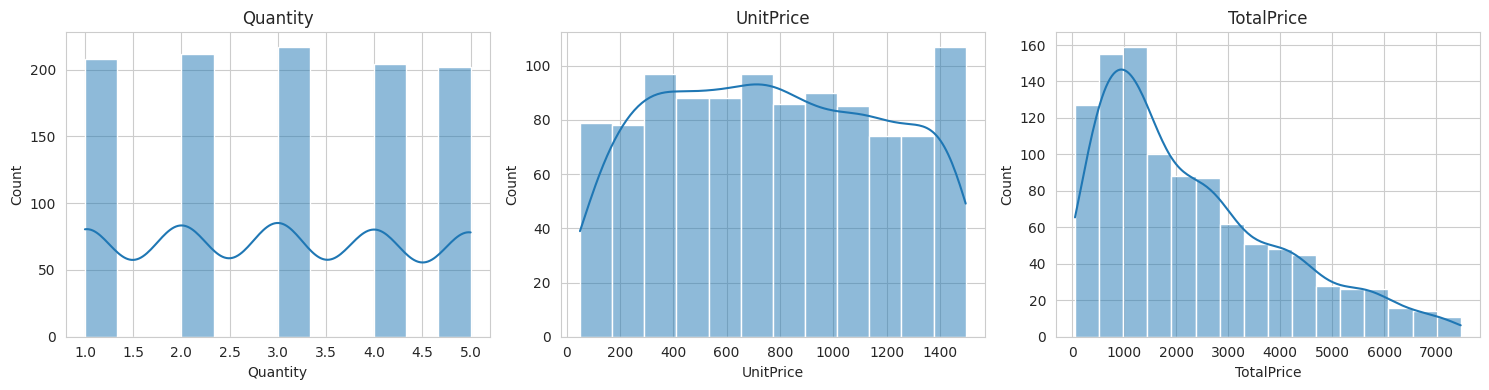

In [4]:
num_vars = ["Quantity", "UnitPrice", "TotalPrice"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_vars):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

Les montants par ligne de commande (`TotalPrice`) sont dispersés, avec une majorité de commandes de faible à moyenne valeur et quelques commandes de montant élevé.

## 3. Agrégation des données au niveau client

Le dataset original contient une ligne par produit commandé. Pour segmenter des **clients** (et non des lignes de commande), on agrège d'abord les données par `CustomerID`.

In [5]:
customer_agg = df.groupby("CustomerID").agg(
    Total_Depense=("TotalPrice", "sum"),
    Nb_Commandes=("OrderID", "nunique"),
    Panier_Moyen=("TotalPrice", "mean"),
    Quantite_Totale=("Quantity", "sum")
).reset_index()

print("Nombre de clients distincts :", customer_agg.shape[0])
customer_agg

Nombre de clients distincts : 8


,CustomerID,Total_Depense,Nb_Commandes,Panier_Moyen,Quantite_Totale
0,C001,324835,68,2303.794326,434
1,C002,266158,54,2274.854701,369
2,C003,328146,56,2625.168000,398
3,C004,247392,61,2151.234783,326
4,C005,312777,65,2250.194245,411
5,C006,325734,65,2310.170213,416
6,C007,283440,62,2304.390244,346
7,C008,309488,69,2179.492958,409


> **Limite importante :** ce jeu de données ne compte que 8 clients distincts. Un clustering sur un échantillon aussi réduit a une valeur essentiellement illustrative — les segments obtenus ne seraient pas statistiquement robustes sur un cas réel. Dans un contexte de production, cette méthode serait appliquée à une base de plusieurs centaines ou milliers de clients pour être fiable.

## 4. Segmentation par clustering (K-Means)

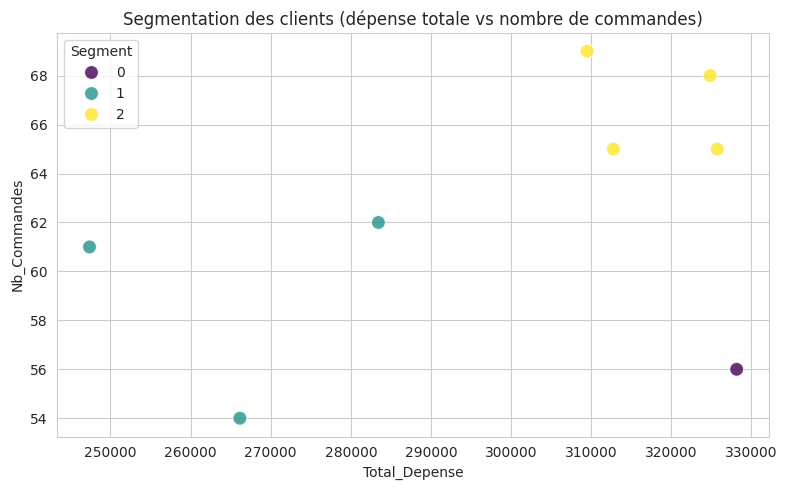

In [6]:
cluster_features = ["Total_Depense", "Nb_Commandes", "Panier_Moyen"]
X = customer_agg[cluster_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_agg["Segment"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 5))
sns.scatterplot(x="Total_Depense", y="Nb_Commandes", hue="Segment",
                data=customer_agg, palette="viridis", s=100, alpha=0.8)
plt.title("Segmentation des clients (dépense totale vs nombre de commandes)")
plt.tight_layout()
plt.show()

In [7]:
cluster_summary = customer_agg.groupby("Segment")[cluster_features].mean()
cluster_counts = customer_agg["Segment"].value_counts().sort_index()
print("Profil moyen par segment :")
print(cluster_summary)
print("\nNombre de clients par segment :")
print(cluster_counts)

Profil moyen par segment :
         Total_Depense  Nb_Commandes  Panier_Moyen
Segment                                           
0        328146.000000         56.00   2625.168000
1        265663.333333         59.00   2243.493242
2        318208.500000         66.75   2260.912935

Nombre de clients par segment :
Segment
0    1
1    3
2    4
Name: count, dtype: int64


## 5. Conclusion

Sur cet échantillon réduit, on distingue tout de même des tendances cohérentes : certains clients génèrent un volume d'affaires sensiblement plus élevé avec un panier moyen supérieur, d'autres commandent plus fréquemment mais pour des montants plus modestes.

**Prochaine étape recommandée :** appliquer cette même méthodologie sur un historique de commandes plus large (idéalement plusieurs centaines de clients) pour obtenir des segments fiables et exploitables commercialement (ex. ciblage marketing différencié par segment).

In [8]:
customer_agg.to_csv("clients_segmentes.csv", index=False)
print("Fichier sauvegardé : clients_segmentes.csv")

Fichier sauvegardé : clients_segmentes.csv
